# Phishing URL Detection: Machine Learning Pipeline

This notebook implements the machine learning pipeline described in the project proposal
*"A Machine Learning-Based System for Phishing URL Detection"*.

**Dataset:** UCI Machine Learning Repository, Phishing Websites Dataset (Option A from the proposal)
11,055 labeled instances, 30 pre-extracted lexical, domain-based, and content-based features.

**Pipeline steps:**
1. Load and explore the dataset
2. Exploratory data analysis
3. Train/test split
4. Train and compare multiple classification algorithms
5. Evaluate using accuracy, precision, recall, F1-score, and ROC-AUC
6. Analyze feature importance
7. Save the best model for use in the demo app (`app.py`)


## 1. Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 2. Load and Explore the Dataset

The dataset (`phishing_dataset.csv`) contains 30 features and a target column `Result`,
where `Result = 1` means the URL/website is **legitimate** and `Result = -1` means it is **phishing**.


In [10]:
df = pd.read_csv("phishing_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (11055, 31)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [11]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
df.describe().T


Missing values per column:
0 total missing values


,count,mean,std,min,25%,50%,75%,max
having_IP_Address,11055.0,0.313795,0.949534,-1.0,-1.0,1.0,1.0,1.0
URL_Length,11055.0,-0.633198,0.766095,-1.0,-1.0,-1.0,-1.0,1.0
Shortining_Service,11055.0,0.738761,0.673998,-1.0,1.0,1.0,1.0,1.0
having_At_Symbol,11055.0,0.700588,0.713598,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.741474,0.671011,-1.0,1.0,1.0,1.0,1.0
Prefix_Suffix,11055.0,-0.734962,0.678139,-1.0,-1.0,-1.0,-1.0,1.0
having_Sub_Domain,11055.0,0.063953,0.817518,-1.0,-1.0,0.0,1.0,1.0
SSLfinal_State,11055.0,0.250927,0.911892,-1.0,-1.0,1.0,1.0,1.0
Domain_registeration_length,11055.0,-0.336771,0.941629,-1.0,-1.0,-1.0,1.0,1.0
Favicon,11055.0,0.628584,0.777777,-1.0,1.0,1.0,1.0,1.0


Result
Legitimate    6157
Phishing      4898
Name: count, dtype: int64


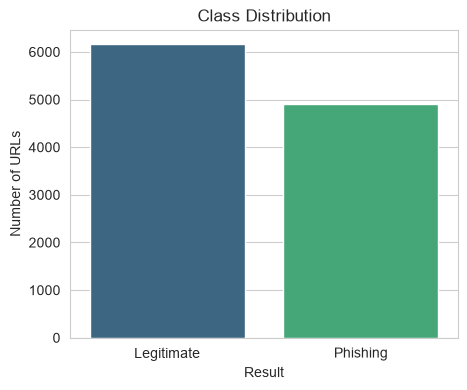

In [12]:
class_counts = df["Result"].value_counts().rename({1: "Legitimate", -1: "Phishing"})
print(class_counts)

plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="viridis", legend=False)
plt.title("Class Distribution")
plt.ylabel("Number of URLs")
plt.savefig(
    "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 3. Exploratory Data Analysis

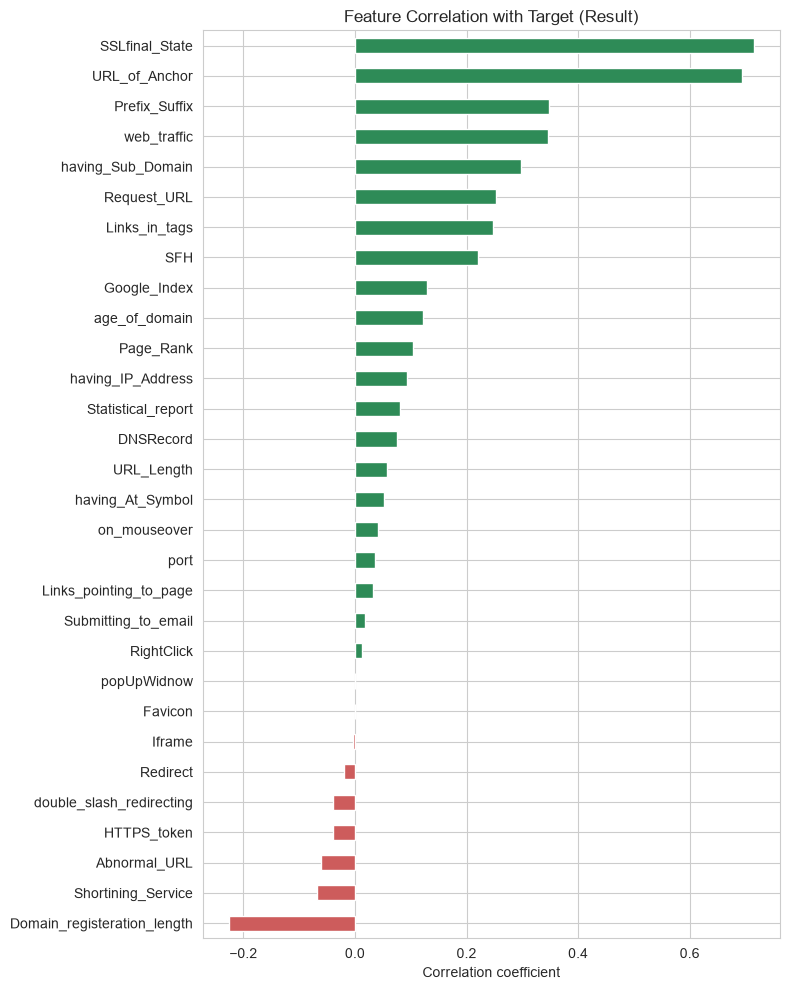

In [13]:
corr = df.corr(numeric_only=True)["Result"].drop("Result").sort_values()

plt.figure(figsize=(8, 10))
corr.plot(kind="barh", color=(corr > 0).map({True: "seagreen", False: "indianred"}))
plt.title("Feature Correlation with Target (Result)")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.savefig(
    "feature_correlation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


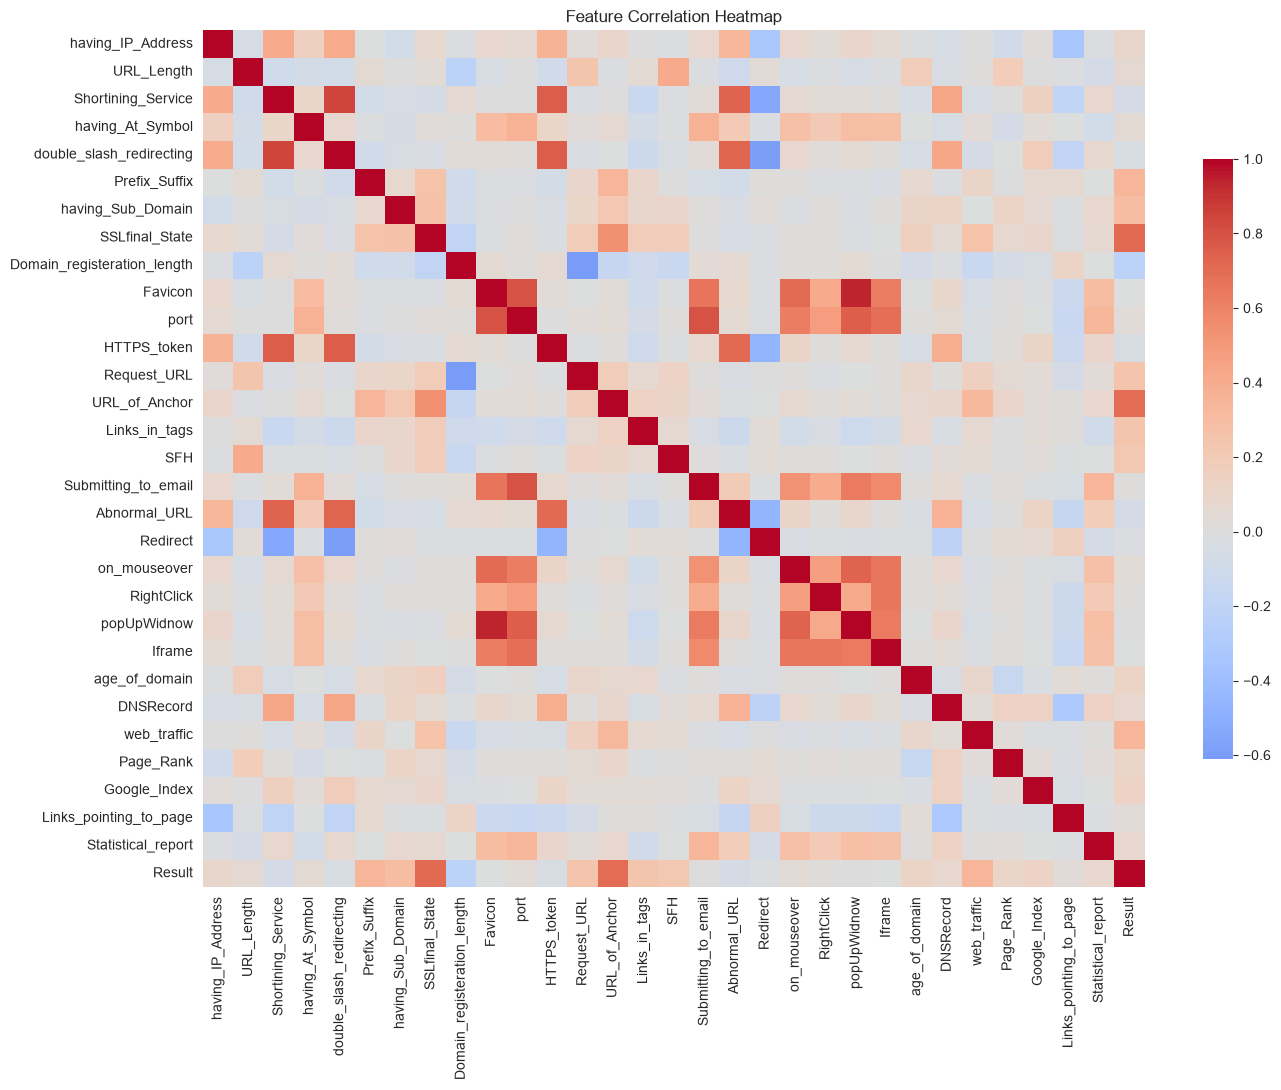

In [14]:
plt.figure(figsize=(14, 11))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0, cbar_kws={"shrink": 0.7})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## 4. Train/Test Split

We map the target to the standard convention `1 = phishing`, `0 = legitimate` for clarity when
interpreting precision/recall (so "positive" means "phishing detected").


In [15]:
X = df.drop(columns=["Result"])
y = df["Result"].map({-1: 1, 1: 0})  # 1 = phishing, 0 = legitimate

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (8844, 30)  Test size: (2211, 30)


## 5. Train and Compare Multiple Models

As proposed, we train and compare five algorithms:
Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, and XGBoost.


In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM": CalibratedClassifierCV(SVC(), ensemble=False),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
}

trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    })

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.976934,0.980352,0.967347,0.973806,0.996385
1,XGBoost,0.976029,0.981308,0.964286,0.972723,0.996684
2,Decision Tree,0.969697,0.976017,0.955102,0.965446,0.976431
3,SVM,0.949796,0.953076,0.932653,0.942754,0.988941
4,Logistic Regression,0.927635,0.934322,0.900000,0.916840,0.978443


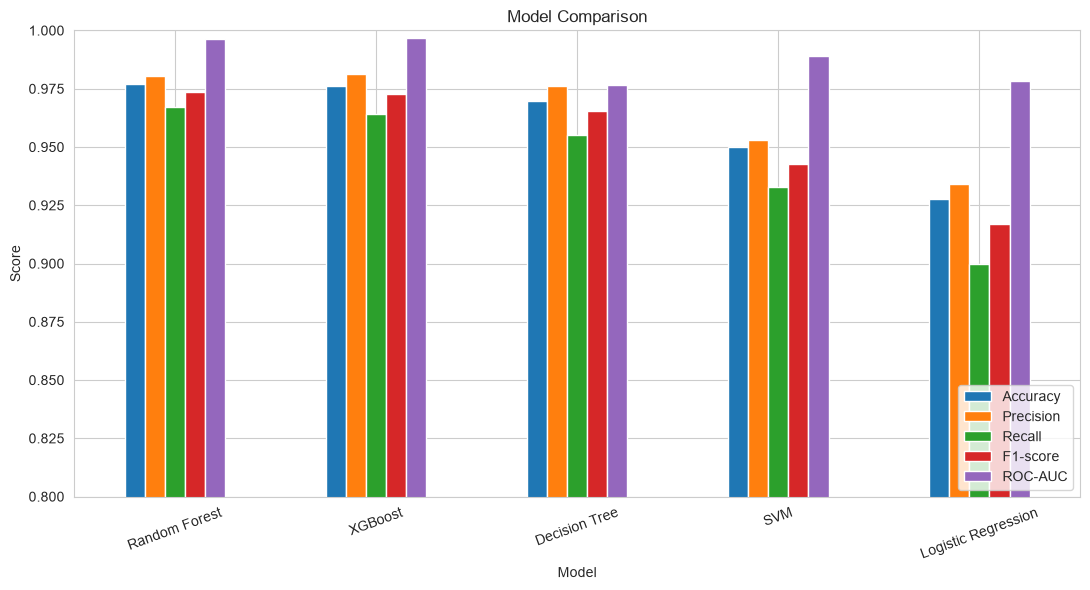

In [17]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]].plot(
    kind="bar", figsize=(11, 6)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 6. Detailed Evaluation of the Best Model

In [18]:
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
print("Best model by F1-score:", best_name)

preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds, target_names=["Legitimate", "Phishing"]))


Best model by F1-score: Random Forest
              precision    recall  f1-score   support

  Legitimate       0.97      0.98      0.98      1231
    Phishing       0.98      0.97      0.97       980

    accuracy                           0.98      2211
   macro avg       0.98      0.98      0.98      2211
weighted avg       0.98      0.98      0.98      2211



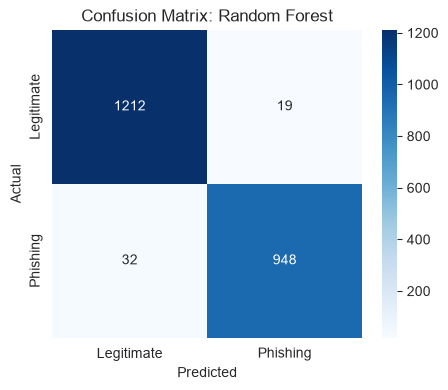

In [19]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitimate", "Phishing"], yticklabels=["Legitimate", "Phishing"])
plt.title(f"Confusion Matrix: {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


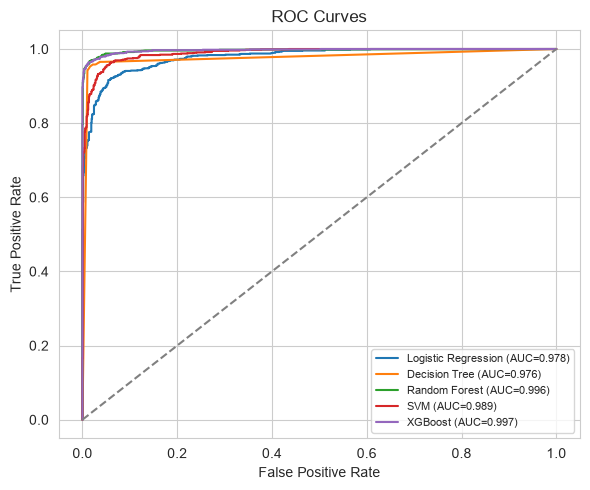

In [20]:
plt.figure(figsize=(6, 5))
for name, model in trained_models.items():
    probs_i = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs_i)
    auc = roc_auc_score(y_test, probs_i)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(
    "ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 7. Feature Importance

Understanding which features drive predictions supports the interpretability objective from the proposal.


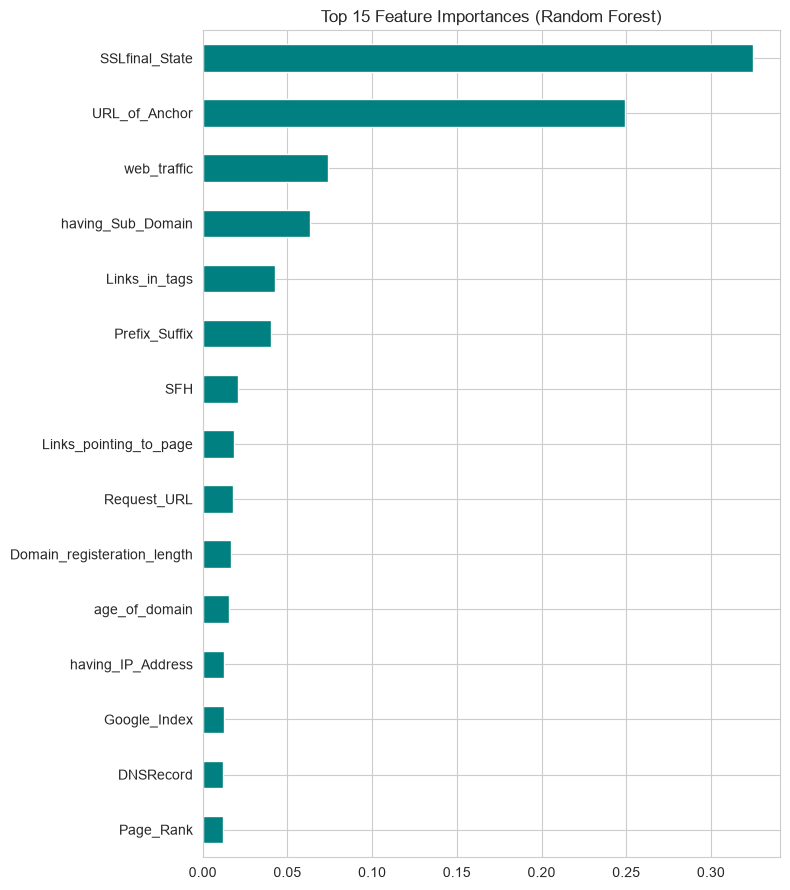

In [21]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=False)
else:
    importances = None

if importances is not None:
    plt.figure(figsize=(8, 9))
    importances.head(15).sort_values().plot(kind="barh", color="teal")
    plt.title(f"Top 15 Feature Importances ({best_name})")
    plt.tight_layout()
    plt.savefig(
        "feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
else:
    print(f"{best_name} does not expose feature importances directly.")


## 8. Cross-Validation Check

A quick 5-fold cross-validation confirms the result is not an artifact of a single train/test split.


In [19]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="f1")
print(f"5-fold CV F1-scores: {cv_scores}")
print(f"Mean F1: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")


5-fold CV F1-scores: [0.98153846 0.97683994 0.97488467 0.95557851 0.9369183 ]
Mean F1: 0.9652  (+/- 0.0167)


## 9. Save the Best Model

The saved model and feature column order are used by `app.py` (the Streamlit demo)
to make real-time predictions on new URLs.


In [22]:
joblib.dump(best_model, "phishing_model.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")
print("Saved phishing_model.pkl and feature_columns.pkl")


Saved phishing_model.pkl and feature_columns.pkl


## 10. Try It on a New URL (optional, requires internet access)

This cell uses `feature_extraction.py` to convert a live URL into the 30 model features
and get a prediction. It requires an active internet connection to fetch the page,
perform DNS/WHOIS lookups, and check the SSL certificate. Some features are approximated
where the original third-party data source (Alexa rank, Google PageRank API) is no
longer available. See the docstring in `feature_extraction.py` for details.


In [20]:
from feature_extraction import extract_features

test_url = "http://example.com"  # replace with any URL to test

try:
    feature_dict, extractor = extract_features(test_url)
    vector = [feature_dict[col] for col in X.columns]
    X_new = pd.DataFrame([vector], columns=X.columns)

    pred = best_model.predict(X_new)[0]
    proba = best_model.predict_proba(X_new)[0]

    label = "PHISHING" if pred == 1 else "LEGITIMATE"
    confidence = proba[1] if pred == 1 else proba[0]
    print(f"URL: {test_url}")
    print(f"Prediction: {label}  (confidence: {confidence:.1%})")
except Exception as e:
    print("Could not fetch/analyze this URL in the current environment:", e)


ModuleNotFoundError: No module named 'dns'

## 11. Conclusion

This notebook implemented the full pipeline proposed for the phishing URL detection project:
data loading, exploratory analysis, training and comparison of five classification algorithms,
evaluation with multiple metrics, feature importance analysis, and model persistence for a
real-time demo application.

Consistent with the proposal's emphasis on minimizing missed phishing sites, model comparison
prioritized F1-score and recall alongside accuracy. The best-performing model and its feature
column order have been saved for use in `app.py`.

**Possible extensions (Option B from the proposal):** build a fresh dataset directly from
PhishTank/OpenPhish and the Tranco top-sites list, and engineer features from raw URLs rather
than relying on the pre-extracted UCI dataset.
